In [1]:
from pathlib import Path
import os
import pandas as pd
import sklearn

base_folder = Path(
    r"C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project"
)

part3_folder = base_folder / "capstone_part3"
part3_folder.mkdir(exist_ok=True)
os.chdir(part3_folder)

raw_csv = (
    base_folder / "capstone_part2"
    / "data" / "Metro_Interstate_Traffic_Volume.csv"
)

df = pd.read_csv(raw_csv, keep_default_na=False)

print("작업 폴더:", Path.cwd())
print("데이터 크기:", df.shape)
print("scikit-learn 버전:", sklearn.__version__)

df.head()

작업 폴더: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part3
데이터 크기: (48204, 9)
scikit-learn 버전: 1.7.2


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
import logging

logger = logging.getLogger("part3_preparation")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(
            part3_folder / "part3.log",
            mode="a",
            encoding="utf-8",
        ),
    ],
    force=True,
)

# 원본 데이터는 유지하고 복사본으로 작업합니다.
data = df.copy()

data["date_time"] = pd.to_datetime(
    data["date_time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="raise",
)

# 모든 열의 값이 동일한 중복만 제거합니다.
before = len(data)
data = data.drop_duplicates().copy()

logger.warning(
    "Removed exact duplicate rows=%d",
    before - len(data),
)

data = data.sort_values("date_time").reset_index(drop=True)

# 고유한 시각을 기준으로 분리합니다.
timestamps = data["date_time"].drop_duplicates().sort_values()
train_end = timestamps.iloc[int(len(timestamps) * 0.70)]
test_start = timestamps.iloc[int(len(timestamps) * 0.85)]

train = data.loc[data["date_time"] < train_end].copy()

validation = data.loc[
    (data["date_time"] >= train_end)
    & (data["date_time"] < test_start)
].copy()

test = data.loc[data["date_time"] >= test_start].copy()

# 분리 구간이 겹치지 않는지 확인합니다.
assert train["date_time"].max() < validation["date_time"].min()
assert validation["date_time"].max() < test["date_time"].min()

for name, subset in [
    ("train", train),
    ("validation", validation),
    ("test", test),
]:
    logger.info(
        "%s | rows=%d | unique timestamps=%d | start=%s | end=%s",
        name,
        len(subset),
        subset["date_time"].nunique(),
        subset["date_time"].min(),
        subset["date_time"].max(),
    )

summary = pd.DataFrame([
    {
        "split": name,
        "rows": len(subset),
        "unique_hours": subset["date_time"].nunique(),
        "start": subset["date_time"].min(),
        "end": subset["date_time"].max(),
    }
    for name, subset in [
        ("train", train),
        ("validation", validation),
        ("test", test),
    ]
])

summary

2026-10-10 22:31:13,082 | WARNING | part3_preparation | Removed exact duplicate rows=17
2026-10-10 22:31:13,153 | INFO | part3_preparation | train | rows=33497 | unique timestamps=28402 | start=2012-10-02 09:00:00 | end=2017-05-10 04:00:00
2026-10-10 22:31:13,156 | INFO | part3_preparation | validation | rows=7274 | unique timestamps=6086 | start=2017-05-10 05:00:00 | end=2018-01-19 14:00:00
2026-10-10 22:31:13,158 | INFO | part3_preparation | test | rows=7416 | unique timestamps=6087 | start=2018-01-19 15:00:00 | end=2018-09-30 23:00:00


,split,rows,unique_hours,start,end
0,train,33497,28402,2012-10-02 09:00:00,2017-05-10 04:00:00
1,validation,7274,6086,2017-05-10 05:00:00,2018-01-19 14:00:00
2,test,7416,6087,2018-01-19 15:00:00,2018-09-30 23:00:00


In [3]:
import numpy as np
import pandas as pd

weather_columns = [
    "temp", "rain_1h", "snow_1h", "clouds_all"
]

# 이상값을 결측값으로 바꾸기
def mark_invalid_weather(frame):
    result = frame.copy()

    for col in weather_columns:
        result[col] = pd.to_numeric(
            result[col], errors="coerce"
        ).replace([np.inf, -np.inf], np.nan)

    result.loc[result["temp"] <= 0, "temp"] = np.nan

    result.loc[
        (result["rain_1h"] < 0) | (result["rain_1h"] > 9000),
        "rain_1h"
    ] = np.nan

    result.loc[result["snow_1h"] < 0, "snow_1h"] = np.nan

    result.loc[
        ~result["clouds_all"].between(0, 100),
        "clouds_all"
    ] = np.nan

    return result


# 중앙값은 학습 데이터에서만 계산
train_checked = mark_invalid_weather(train)

monthly_medians = train_checked.groupby(
    train_checked["date_time"].dt.month
)[weather_columns].median()

overall_medians = train_checked[weather_columns].median()

if overall_medians.isna().any():
    raise ValueError("학습 데이터에서 중앙값을 계산할 수 없는 열이 있습니다.")


# 학습 데이터의 기준을 모든 구간에 적용
def clean_weather(frame, split_name):
    result = mark_invalid_weather(frame)
    month = result["date_time"].dt.month

    for col in weather_columns:
        missing_count = int(result[col].isna().sum())

        result[col] = (
            result[col]
            .fillna(month.map(monthly_medians[col]))
            .fillna(overall_medians[col])
        )

        if missing_count:
            logger.warning(
                "%s: filled %d invalid/missing values in %s",
                split_name, missing_count, col
            )

    logger.info(
        "%s: weather cleaning completed, rows=%d",
        split_name, len(result)
    )
    return result


train_clean = clean_weather(train, "train")
validation_clean = clean_weather(validation, "validation")
test_clean = clean_weather(test, "test")

# 결과 확인: 모든 칸이 0이면 결측값 처리 완료
pd.DataFrame({
    "train_missing": train_clean[weather_columns].isna().sum(),
    "validation_missing": validation_clean[weather_columns].isna().sum(),
    "test_missing": test_clean[weather_columns].isna().sum()
})

2026-10-10 22:36:28,809 | WARNING | part3_preparation | train: filled 10 invalid/missing values in temp
2026-10-10 22:36:28,813 | WARNING | part3_preparation | train: filled 1 invalid/missing values in rain_1h
2026-10-10 22:36:28,818 | INFO | part3_preparation | train: weather cleaning completed, rows=33497
2026-10-10 22:36:28,834 | INFO | part3_preparation | validation: weather cleaning completed, rows=7274
2026-10-10 22:36:28,848 | INFO | part3_preparation | test: weather cleaning completed, rows=7416


,train_missing,validation_missing,test_missing
temp,0,0,0
rain_1h,0,0,0
snow_1h,0,0,0
clouds_all,0,0,0


In [4]:
def create_features(frame):
    result = frame.copy()
    dt = result["date_time"]

    # 시간과 요일: 월요일=0, 일요일=6
    result["hour"] = dt.dt.hour
    result["day_of_week"] = dt.dt.dayofweek
    result["month"] = dt.dt.month
    result["is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)

    # 순환 특성: 23시와 0시, 일요일과 월요일의 연결 표현
    result["hour_sin"] = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"] = np.sin(
        2 * np.pi * result["day_of_week"] / 7
    )
    result["dow_cos"] = np.cos(
        2 * np.pi * result["day_of_week"] / 7
    )

    # 날씨 문자열 통일
    for col in ["holiday", "weather_main", "weather_description"]:
        result[col] = (
            result[col].fillna("unknown")
            .astype(str).str.strip().str.lower()
        )

    # 데이터에 표시된 공휴일을 해당 날짜 전체에 적용
    holiday_mask = ~result["holiday"].isin(
        ["none", "unknown", "", "nan"]
    )
    holiday_dates = set(
        result.loc[holiday_mask, "date_time"].dt.date
    )
    result["is_holiday"] = (
        dt.dt.date.isin(holiday_dates).astype(int)
    )

    # 날씨 특성
    result["temp_c"] = result["temp"] - 273.15
    result["is_raining"] = (result["rain_1h"] > 0).astype(int)
    result["is_snowing"] = (result["snow_1h"] > 0).astype(int)

    # 관측 시정 거리가 없으므로 날씨 분류를 이용한 대리 지표
    result["is_low_visibility"] = (
        result["weather_main"]
        .isin(["mist", "fog", "haze", "smoke"])
        .astype(int)
    )

    return result


train_features = create_features(train_clean)
validation_features = create_features(validation_clean)
test_features = create_features(test_clean)

# 모델 입력에 사용할 열
numeric_features = [
    "hour", "day_of_week", "month",
    "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "temp_c", "rain_1h", "snow_1h", "clouds_all",
    "is_raining", "is_snowing", "is_low_visibility"
]

categorical_features = ["weather_main"]
feature_columns = numeric_features + categorical_features

# 예측할 교통량은 입력 특성에서 제외
assert "traffic_volume" not in feature_columns

for name, frame in [
    ("train", train_features),
    ("validation", validation_features),
    ("test", test_features)
]:
    assert frame[feature_columns].isna().sum().sum() == 0
    logger.info(
        "%s: feature creation completed | rows=%d | input features=%d",
        name, len(frame), len(feature_columns)
    )

train_features[
    ["date_time", "hour", "day_of_week", "is_weekend",
     "is_holiday", "temp_c", "weather_main"]
].head()

2026-10-10 22:41:15,441 | INFO | part3_preparation | train: feature creation completed | rows=33497 | input features=17
2026-10-10 22:41:15,449 | INFO | part3_preparation | validation: feature creation completed | rows=7274 | input features=17
2026-10-10 22:41:15,456 | INFO | part3_preparation | test: feature creation completed | rows=7416 | input features=17


,date_time,hour,day_of_week,is_weekend,is_holiday,temp_c,weather_main
0,2012-10-02 09:00:00,9,1,0,0,15.13,clouds
1,2012-10-02 10:00:00,10,1,0,0,16.21,clouds
2,2012-10-02 11:00:00,11,1,0,0,16.43,clouds
3,2012-10-02 12:00:00,12,1,0,0,16.98,clouds
4,2012-10-02 13:00:00,13,1,0,0,17.99,clouds


In [5]:
# 학습 데이터에서만 사분위수 계산
q1, q2, q3 = train_features["traffic_volume"].quantile(
    [0.25, 0.50, 0.75]
).values

logger.info(
    "Training congestion thresholds: Q1=%.2f, Q2=%.2f, Q3=%.2f",
    q1, q2, q3
)

# 프로젝트에서 정한 악천후 대리 기준
# 실제 날씨의 강도나 사고 발생을 측정하는 기준은 아님
SEVERE_WEATHER = {"thunderstorm", "snow", "squall"}

def create_labels(frame):
    result = frame.copy()
    volume = result["traffic_volume"]

    if volume.isna().any() or (volume < 0).any():
        raise ValueError("교통량에 결측값 또는 음수가 있습니다.")

    result["congestion_category"] = np.select(
        [
            volume <= q1,
            volume <= q2,
            volume <= q3
        ],
        ["Low", "Medium", "High"],
        default="Severe"
    )

    high_congestion = result["congestion_category"].isin(
        ["High", "Severe"]
    )

    risky_weather = (
        result["weather_main"].isin(SEVERE_WEATHER)
        | (result["is_low_visibility"] == 1)
    )

    # 1: 높은 교통량과 악천후/낮은 시정 조건이 동시에 존재
    # 0: 위 조건을 충족하지 않음
    result["high_risk"] = (
        high_congestion & risky_weather
    ).astype(int)

    return result


train_features = create_labels(train_features)
validation_features = create_labels(validation_features)
test_features = create_labels(test_features)

# 정답에서 파생된 열은 모델 입력에서 제외
assert not {
    "traffic_volume", "congestion_category", "high_risk"
}.intersection(feature_columns)

label_summary = []

for name, frame in [
    ("train", train_features),
    ("validation", validation_features),
    ("test", test_features)
]:
    positive_count = int(frame["high_risk"].sum())

    label_summary.append({
        "split": name,
        "rows": len(frame),
        "proxy_0": len(frame) - positive_count,
        "proxy_1": positive_count,
        "proxy_1_percent": round(
            100 * frame["high_risk"].mean(), 2
        )
    })

    logger.info(
        "%s: labels created | proxy_1=%d",
        name, positive_count
    )

pd.DataFrame(label_summary)

2026-10-10 22:43:20,316 | INFO | part3_preparation | Training congestion thresholds: Q1=1160.00, Q2=3331.00, Q3=4924.00
2026-10-10 22:43:20,394 | INFO | part3_preparation | train: labels created | proxy_1=3688
2026-10-10 22:43:20,396 | INFO | part3_preparation | validation: labels created | proxy_1=903
2026-10-10 22:43:20,399 | INFO | part3_preparation | test: labels created | proxy_1=895


,split,rows,proxy_0,proxy_1,proxy_1_percent
0,train,33497,29809,3688,11.01
1,validation,7274,6371,903,12.41
2,test,7416,6521,895,12.07


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
import time

# 모델 입력과 예측 대상
X_train = train_features[feature_columns].copy()
X_validation = validation_features[feature_columns].copy()

y_train_reg = train_features["traffic_volume"].copy()
y_validation_reg = validation_features["traffic_volume"].copy()

# 숫자 표준화 + 날씨 범주 인코딩
# 아래 Pipeline.fit에서 학습 데이터로만 기준을 계산
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

regression_algorithms = {
    "Ridge": Ridge(alpha=1.0),

    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=16,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

regression_models = {}
regression_results = []

for name, algorithm in regression_algorithms.items():
    logger.info("Training regression model: %s", name)
    started = time.perf_counter()

    model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", algorithm)
    ])

    model.fit(X_train, y_train_reg)
    training_seconds = time.perf_counter() - started

    predictions = model.predict(X_validation)

    mae = mean_absolute_error(y_validation_reg, predictions)
    r2 = r2_score(y_validation_reg, predictions)

    regression_models[name] = model

    regression_results.append({
        "model": name,
        "validation_MAE": mae,
        "validation_R2": r2,
        "training_seconds": training_seconds
    })

    logger.info(
        "%s completed | validation MAE=%.2f | R2=%.4f",
        name, mae, r2
    )

regression_comparison = (
    pd.DataFrame(regression_results)
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

# 검증 MAE가 가장 낮은 모델 선택
best_regression_name = regression_comparison.loc[0, "model"]
best_regression_model = regression_models[best_regression_name]

logger.info(
    "Selected regression model by validation MAE: %s",
    best_regression_name
)

# 비교 결과 저장
reports_folder = part3_folder / "reports"
reports_folder.mkdir(parents=True, exist_ok=True)

regression_comparison.to_csv(
    reports_folder / "regression_validation_metrics.csv",
    index=False
)

regression_comparison.round(4)

2026-10-10 22:48:50,922 | INFO | part3_preparation | Training regression model: Ridge
2026-10-10 22:48:51,122 | INFO | part3_preparation | Ridge completed | validation MAE=813.41 | R2=0.7242
2026-10-10 22:48:51,125 | INFO | part3_preparation | Training regression model: RandomForest
2026-10-10 22:48:54,042 | INFO | part3_preparation | RandomForest completed | validation MAE=249.84 | R2=0.9587
2026-10-10 22:48:54,049 | INFO | part3_preparation | Selected regression model by validation MAE: RandomForest


,model,validation_MAE,validation_R2,training_seconds
0,RandomForest,249.8408,0.9587,2.8326
1,Ridge,813.4129,0.7242,0.1819


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 앞서 만든 동일한 입력 특성을 사용
y_train_cls = train_features["high_risk"].copy()
y_validation_cls = validation_features["high_risk"].copy()

classification_algorithms = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=16,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

classification_models = {}
classification_results = []

for name, algorithm in classification_algorithms.items():
    logger.info("Training classification model: %s", name)
    started = time.perf_counter()

    model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", algorithm)
    ])

    # 전처리와 모델 모두 학습 데이터로만 학습
    model.fit(X_train, y_train_cls)
    training_seconds = time.perf_counter() - started

    # 두 모델 모두 같은 임계값 0.5 적용
    probabilities = model.predict_proba(X_validation)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    scores = {
        "model": name,
        "validation_accuracy": accuracy_score(
            y_validation_cls, predictions
        ),
        "validation_precision": precision_score(
            y_validation_cls, predictions, zero_division=0
        ),
        "validation_recall": recall_score(
            y_validation_cls, predictions, zero_division=0
        ),
        "validation_F1": f1_score(
            y_validation_cls, predictions, zero_division=0
        ),
        "validation_ROC_AUC": roc_auc_score(
            y_validation_cls, probabilities
        ),
        "training_seconds": training_seconds
    }

    classification_models[name] = model
    classification_results.append(scores)

    logger.info(
        "%s completed | validation F1=%.4f | ROC AUC=%.4f",
        name,
        scores["validation_F1"],
        scores["validation_ROC_AUC"]
    )

classification_comparison = (
    pd.DataFrame(classification_results)
    .sort_values(
        ["validation_F1", "validation_ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

best_classification_name = classification_comparison.loc[0, "model"]
best_classification_model = classification_models[
    best_classification_name
]

logger.info(
    "Selected classification model by validation F1: %s",
    best_classification_name
)

classification_comparison.to_csv(
    reports_folder / "classification_validation_metrics.csv",
    index=False
)

classification_comparison.round(4)

2026-10-10 22:51:14,243 | INFO | part3_preparation | Training classification model: LogisticRegression
2026-10-10 22:51:14,640 | INFO | part3_preparation | LogisticRegression completed | validation F1=0.8898 | ROC AUC=0.9965
2026-10-10 22:51:14,641 | INFO | part3_preparation | Training classification model: RandomForest
2026-10-10 22:51:15,401 | INFO | part3_preparation | RandomForest completed | validation F1=0.9599 | ROC AUC=0.9986
2026-10-10 22:51:15,418 | INFO | part3_preparation | Selected classification model by validation F1: RandomForest


,model,validation_accuracy,validation_precision,validation_recall,validation_F1,validation_ROC_AUC,training_seconds
0,RandomForest,0.9900,0.9531,0.9668,0.9599,0.9986,0.6565
1,LogisticRegression,0.9698,0.8124,0.9834,0.8898,0.9965,0.3477


In [8]:
import joblib

# 학습과 모델 선택에 사용하지 않은 테스트 데이터
X_test = test_features[feature_columns].copy()
y_test_reg = test_features["traffic_volume"].copy()
y_test_cls = test_features["high_risk"].copy()

# 회귀 모델 평가
reg_test_predictions = best_regression_model.predict(X_test)

regression_test_results = pd.DataFrame([{
    "model": best_regression_name,
    "test_MAE": mean_absolute_error(
        y_test_reg, reg_test_predictions
    ),
    "test_R2": r2_score(
        y_test_reg, reg_test_predictions
    )
}])

# 분류 모델 평가: 기존 임계값 0.5 유지
cls_test_probabilities = (
    best_classification_model.predict_proba(X_test)[:, 1]
)
cls_test_predictions = (
    cls_test_probabilities >= 0.5
).astype(int)

classification_test_results = pd.DataFrame([{
    "model": best_classification_name,
    "test_accuracy": accuracy_score(
        y_test_cls, cls_test_predictions
    ),
    "test_precision": precision_score(
        y_test_cls, cls_test_predictions, zero_division=0
    ),
    "test_recall": recall_score(
        y_test_cls, cls_test_predictions, zero_division=0
    ),
    "test_F1": f1_score(
        y_test_cls, cls_test_predictions, zero_division=0
    ),
    "test_ROC_AUC": roc_auc_score(
        y_test_cls, cls_test_probabilities
    )
}])

# 평가 결과 저장
regression_test_results.to_csv(
    reports_folder / "regression_test_metrics.csv",
    index=False
)
classification_test_results.to_csv(
    reports_folder / "classification_test_metrics.csv",
    index=False
)

# 나중에 오류 분석에 사용할 개별 예측 결과 저장
test_predictions = test_features[
    ["date_time", "weather_main", "is_weekend"]
].copy()

test_predictions["actual_volume"] = y_test_reg
test_predictions["predicted_volume"] = reg_test_predictions
test_predictions["actual_proxy_label"] = y_test_cls
test_predictions["predicted_proxy_label"] = cls_test_predictions
test_predictions["proxy_score"] = cls_test_probabilities

test_predictions.to_csv(
    reports_folder / "test_predictions.csv",
    index=False
)

# 학습된 전처리와 모델 저장
models_folder = part3_folder / "models"
models_folder.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_regression_model,
    models_folder / "traffic_regression.joblib",
    compress=3
)
joblib.dump(
    best_classification_model,
    models_folder / "proxy_classification.joblib",
    compress=3
)

# 날씨 보정 기준과 입력 열도 함께 보관
joblib.dump(
    {
        "monthly_medians": monthly_medians,
        "overall_medians": overall_medians,
        "feature_columns": feature_columns,
        "quartiles": [float(q1), float(q2), float(q3)],
        "severe_weather": sorted(SEVERE_WEATHER),
        "classification_threshold": 0.5
    },
    models_folder / "preparation_settings.joblib",
    compress=3
)

logger.info(
    "Test evaluation completed; metrics, predictions and models saved."
)

display(regression_test_results.round(4))
display(classification_test_results.round(4))

2026-10-10 22:54:43,720 | INFO | part3_preparation | Test evaluation completed; metrics, predictions and models saved.


,model,test_MAE,test_R2
0,RandomForest,246.6023,0.951


,model,test_accuracy,test_precision,test_recall,test_F1,test_ROC_AUC
0,RandomForest,0.9784,0.8621,0.9777,0.9162,0.9954


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 학습 구간으로 교통 패턴 분석
cluster_data = train_features.copy()

cluster_columns = [
    "traffic_volume",
    "hour_sin", "hour_cos",
    "is_weekend",
    "temp_c",
    "clouds_all"
]

# 단위 차이가 군집화를 지배하지 않도록 표준화
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(
    cluster_data[cluster_columns]
)

cluster_candidates = {}
cluster_scores = []

for k in range(2, 7):
    logger.info("Training K-means: k=%d", k)

    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(cluster_scaled)

    # 계산 시간을 줄이기 위해 같은 무작위 표본으로 평가
    score = silhouette_score(
        cluster_scaled,
        labels,
        sample_size=min(3000, len(cluster_data)),
        random_state=42
    )

    cluster_candidates[k] = kmeans
    cluster_scores.append({
        "k": k,
        "silhouette_score": score,
        "inertia": kmeans.inertia_
    })

    logger.info(
        "K-means completed: k=%d, silhouette=%.4f",
        k, score
    )

cluster_comparison = (
    pd.DataFrame(cluster_scores)
    .sort_values("silhouette_score", ascending=False)
    .reset_index(drop=True)
)

best_k = int(cluster_comparison.loc[0, "k"])
best_kmeans = cluster_candidates[best_k]

cluster_data["cluster"] = best_kmeans.labels_

# 그룹별 특징 요약
cluster_summary = (
    cluster_data.groupby("cluster")
    .agg(
        records=("traffic_volume", "size"),
        avg_traffic=("traffic_volume", "mean"),
        avg_temp_c=("temp_c", "mean"),
        avg_clouds=("clouds_all", "mean"),
        weekend_share=("is_weekend", "mean"),
        most_common_hour=("hour", lambda s: s.mode().iloc[0]),
        most_common_weather=(
            "weather_main", lambda s: s.mode().iloc[0]
        )
    )
    .reset_index()
)

# 결과와 모델 저장
cluster_comparison.to_csv(
    reports_folder / "kmeans_comparison.csv",
    index=False
)

cluster_summary.to_csv(
    reports_folder / "kmeans_cluster_summary.csv",
    index=False
)

joblib.dump(
    {
        "scaler": cluster_scaler,
        "model": best_kmeans,
        "columns": cluster_columns
    },
    models_folder / "traffic_kmeans.joblib",
    compress=3
)

logger.info("Selected K-means cluster count: %d", best_k)

display(cluster_comparison.round(4))
display(cluster_summary.round(2))

2026-10-10 22:58:27,141 | INFO | part3_preparation | Training K-means: k=2
2026-10-10 22:58:33,324 | INFO | part3_preparation | K-means completed: k=2, silhouette=0.2525
2026-10-10 22:58:33,325 | INFO | part3_preparation | Training K-means: k=3
2026-10-10 22:58:33,883 | INFO | part3_preparation | K-means completed: k=3, silhouette=0.2645
2026-10-10 22:58:33,885 | INFO | part3_preparation | Training K-means: k=4
2026-10-10 22:58:34,498 | INFO | part3_preparation | K-means completed: k=4, silhouette=0.2205
2026-10-10 22:58:34,499 | INFO | part3_preparation | Training K-means: k=5
2026-10-10 22:58:35,024 | INFO | part3_preparation | K-means completed: k=5, silhouette=0.2404
2026-10-10 22:58:35,026 | INFO | part3_preparation | Training K-means: k=6
2026-10-10 22:58:35,570 | INFO | part3_preparation | K-means completed: k=6, silhouette=0.2449
2026-10-10 22:58:35,711 | INFO | part3_preparation | Selected K-means cluster count: 3


,k,silhouette_score,inertia
0,3,0.2645,126021.6331
1,2,0.2525,149715.7215
2,6,0.2449,91196.3171
3,5,0.2404,100326.1579
4,4,0.2205,112453.4590


,cluster,records,avg_traffic,avg_temp_c,avg_clouds,weekend_share,most_common_hour,most_common_weather
0,0,12820,5229.06,7.78,53.38,0.0,10,clouds
1,1,9505,2532.90,7.04,48.45,1.0,7,clouds
2,2,11172,1550.61,5.85,48.93,0.0,23,clouds


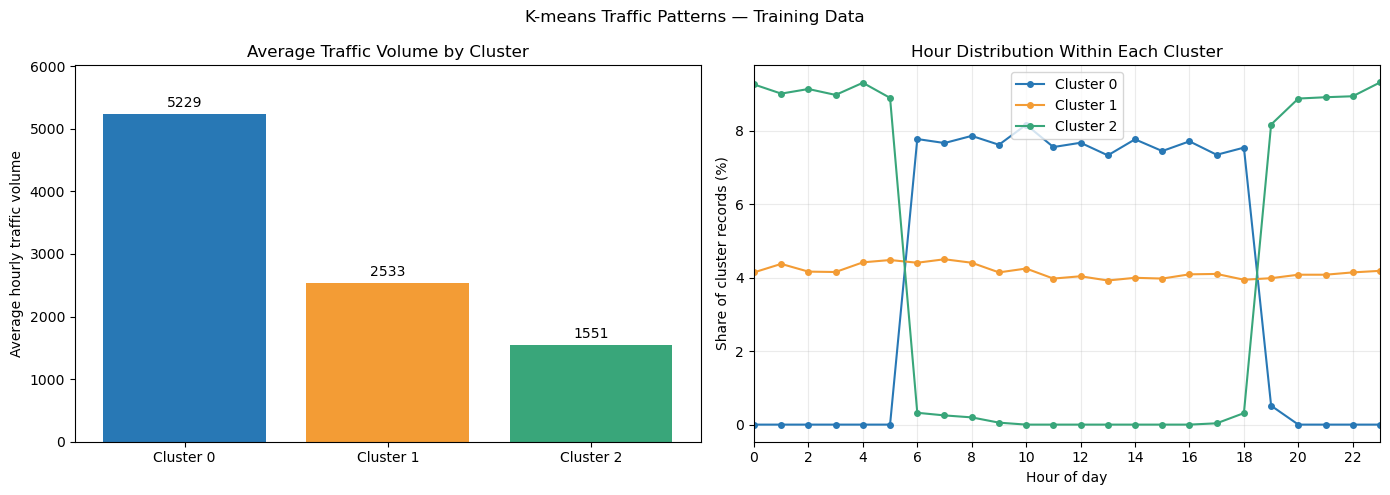

2026-10-10 23:02:27,572 | INFO | part3_preparation | Saved cluster visualization: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part3\figures\kmeans_cluster_patterns.png


In [11]:
import matplotlib.pyplot as plt

figures_folder = part3_folder / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

cluster_ids = sorted(cluster_data["cluster"].unique())
colors = ["#2878B5", "#F39C35", "#39A67A", "#9564BF", "#D65F5F", "#777777"]
cluster_colors = {
    cluster_id: colors[i]
    for i, cluster_id in enumerate(cluster_ids)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 군집별 평균 교통량
means = (
    cluster_data.groupby("cluster")["traffic_volume"]
    .mean()
    .reindex(cluster_ids)
)

bars = axes[0].bar(
    [f"Cluster {c}" for c in cluster_ids],
    means.values,
    color=[cluster_colors[c] for c in cluster_ids]
)

axes[0].bar_label(bars, fmt="%.0f", padding=3)
axes[0].set_title("Average Traffic Volume by Cluster")
axes[0].set_ylabel("Average hourly traffic volume")
axes[0].set_ylim(0, means.max() * 1.15)

# 오른쪽: 각 군집 안에서 시간대별 기록이 차지하는 비율
hour_counts = pd.crosstab(
    cluster_data["hour"],
    cluster_data["cluster"]
).reindex(index=range(24), columns=cluster_ids, fill_value=0)

hour_shares = hour_counts.div(hour_counts.sum(axis=0), axis=1) * 100

for cluster_id in cluster_ids:
    axes[1].plot(
        hour_shares.index,
        hour_shares[cluster_id],
        marker="o",
        markersize=4,
        color=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id}"
    )

axes[1].set_title("Hour Distribution Within Each Cluster")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Share of cluster records (%)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlim(0, 23)
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle("K-means Traffic Patterns — Training Data")
fig.tight_layout()

figure_path = figures_folder / "kmeans_cluster_patterns.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

hour_shares.to_csv(
    reports_folder / "kmeans_hour_distribution.csv",
    index_label="hour"
)

logger.info("Saved cluster visualization: %s", figure_path)

In [12]:
from itertools import combinations

# 학습 구간에서 규칙 탐색
rule_data = train_features.copy()

rule_data["time_band"] = pd.cut(
    rule_data["hour"],
    bins=[-1, 5, 9, 15, 19, 23],
    labels=[
        "Night_00_05",
        "Morning_06_09",
        "Midday_10_15",
        "Evening_16_19",
        "Late_20_23"
    ]
).astype(str)

rule_data["day_type"] = np.where(
    rule_data["is_weekend"] == 1,
    "Weekend",
    "Weekday"
)

condition_columns = ["time_band", "day_type", "weather_main"]

# 규칙 전체가 전체 기록의 1% 이상에서 나타나고,
# 조건을 만족할 때 결과가 나타나는 비율이 60% 이상인 규칙
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.60

total_records = len(rule_data)
base_rates = (
    rule_data["congestion_category"].value_counts(normalize=True)
)

rule_rows = []

# 조건 1개, 2개, 3개의 모든 조합 탐색
for size in range(1, 4):
    for columns in combinations(condition_columns, size):
        columns = list(columns)

        for keys, group in rule_data.groupby(
            columns, observed=True
        ):
            if not isinstance(keys, tuple):
                keys = (keys,)

            antecedent = " AND ".join(
                f"{col}={value}"
                for col, value in zip(columns, keys)
            )

            for category, joint_count in (
                group["congestion_category"].value_counts().items()
            ):
                support = joint_count / total_records
                confidence = joint_count / len(group)
                lift = confidence / base_rates[category]

                if (
                    support >= MIN_SUPPORT
                    and confidence >= MIN_CONFIDENCE
                    and lift > 1
                ):
                    rule_rows.append({
                        "antecedent": antecedent,
                        "consequent": f"congestion={category}",
                        "condition_count": len(group),
                        "joint_count": int(joint_count),
                        "support": support,
                        "confidence": confidence,
                        "lift": lift
                    })

rules = pd.DataFrame(
    rule_rows,
    columns=[
        "antecedent", "consequent",
        "condition_count", "joint_count",
        "support", "confidence", "lift"
    ]
).sort_values(
    ["lift", "support"], ascending=False
).reset_index(drop=True)

rules.to_csv(
    reports_folder / "association_rules.csv",
    index=False
)

# 관심 대상: 높은 교통량 구간으로 이어지는 규칙
high_traffic_rules = rules[
    rules["consequent"].isin(
        ["congestion=High", "congestion=Severe"]
    )
].copy()

high_traffic_rules.to_csv(
    reports_folder / "high_traffic_association_rules.csv",
    index=False
)

logger.info(
    "Association rules saved | all=%d | high/severe=%d",
    len(rules), len(high_traffic_rules)
)

display(high_traffic_rules.head(10).round(4))

2026-10-10 23:05:02,103 | INFO | part3_preparation | Association rules saved | all=41 | high/severe=13


,antecedent,consequent,condition_count,joint_count,support,confidence,lift
3,time_band=Morning_06_09 AND day_type=Weekday A...,congestion=Severe,922,794,0.0237,0.8612,3.4464
4,time_band=Morning_06_09 AND day_type=Weekday A...,congestion=Severe,452,389,0.0116,0.8606,3.4442
24,time_band=Morning_06_09 AND day_type=Weekday A...,congestion=Severe,732,602,0.0180,0.8224,3.2913
27,time_band=Morning_06_09 AND day_type=Weekday,congestion=Severe,4057,3320,0.0991,0.8183,3.2750
28,time_band=Morning_06_09 AND day_type=Weekday A...,congestion=Severe,1233,999,0.0298,0.8102,3.2425
29,time_band=Midday_10_15 AND day_type=Weekend AN...,congestion=High,917,742,0.0222,0.8092,3.2367
32,time_band=Midday_10_15 AND day_type=Weekend AN...,congestion=High,628,502,0.0150,0.7994,3.1975
33,time_band=Midday_10_15 AND day_type=Weekend,congestion=High,2302,1817,0.0542,0.7893,3.1573
35,time_band=Evening_16_19 AND day_type=Weekend A...,congestion=High,604,469,0.0140,0.7765,3.1061
36,time_band=Evening_16_19 AND day_type=Weekend,congestion=High,1533,1122,0.0335,0.7319,2.9277


In [13]:
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None
):
    display(high_traffic_rules.head(3).round(4))

,antecedent,consequent,condition_count,joint_count,support,confidence,lift
3,time_band=Morning_06_09 AND day_type=Weekday AND weather_main=clear,congestion=Severe,922,794,0.0237,0.8612,3.4464
4,time_band=Morning_06_09 AND day_type=Weekday AND weather_main=rain,congestion=Severe,452,389,0.0116,0.8606,3.4442
24,time_band=Morning_06_09 AND day_type=Weekday AND weather_main=mist,congestion=Severe,732,602,0.0180,0.8224,3.2913


2026-10-10 23:08:52,488 | INFO | part3_preparation | Training neural network: hidden layers=(64, 32)


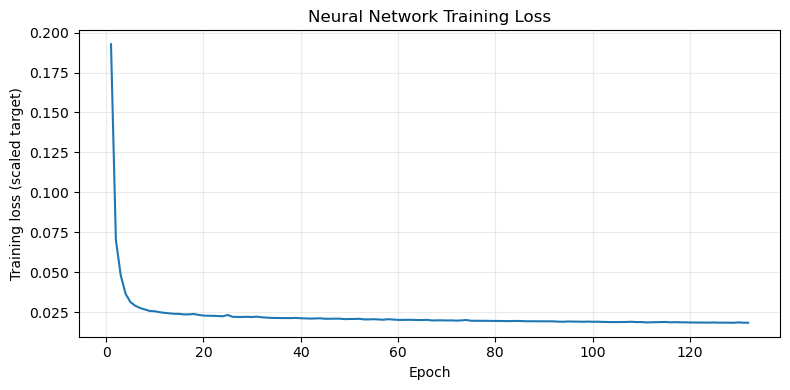

2026-10-10 23:09:34,886 | INFO | part3_preparation | Neural network completed | epochs=132 | validation MAE=279.05 | R2=0.9527


,model,validation_MAE,validation_R2,training_seconds
0,RandomForest,249.8408,0.9587,2.8326
1,NeuralNetwork_MLP,279.0521,0.9527,41.7098
2,Ridge,813.4129,0.7242,0.1819


In [14]:
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor

# 입력 특성 표준화와 날씨 인코딩
nn_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=False,
        n_iter_no_change=20,
        random_state=42
    ))
])

# 교통량도 학습 데이터 기준으로 표준화
# predict() 결과는 원래 교통량 단위로 자동 복원
neural_network_model = TransformedTargetRegressor(
    regressor=nn_pipeline,
    transformer=StandardScaler()
)

logger.info("Training neural network: hidden layers=(64, 32)")
started = time.perf_counter()

neural_network_model.fit(X_train, y_train_reg)

nn_training_seconds = time.perf_counter() - started

nn_validation_predictions = neural_network_model.predict(
    X_validation
)

nn_mae = mean_absolute_error(
    y_validation_reg, nn_validation_predictions
)
nn_r2 = r2_score(
    y_validation_reg, nn_validation_predictions
)

nn_validation_results = pd.DataFrame([{
    "model": "NeuralNetwork_MLP",
    "validation_MAE": nn_mae,
    "validation_R2": nn_r2,
    "training_seconds": nn_training_seconds
}])

# 앞선 두 모델과 비교
all_regression_comparison = pd.concat(
    [regression_comparison, nn_validation_results],
    ignore_index=True
).sort_values("validation_MAE").reset_index(drop=True)

all_regression_comparison.to_csv(
    reports_folder / "regression_with_neural_network.csv",
    index=False
)

joblib.dump(
    neural_network_model,
    models_folder / "traffic_neural_network.joblib",
    compress=3
)

# 학습 손실 그래프
fitted_mlp = (
    neural_network_model.regressor_.named_steps["model"]
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    range(1, len(fitted_mlp.loss_curve_) + 1),
    fitted_mlp.loss_curve_
)
ax.set_title("Neural Network Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (scaled target)")
ax.grid(alpha=0.25)
fig.tight_layout()

fig.savefig(
    figures_folder / "neural_network_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

logger.info(
    "Neural network completed | epochs=%d | validation MAE=%.2f | R2=%.4f",
    fitted_mlp.n_iter_, nn_mae, nn_r2
)

display(all_regression_comparison.round(4))

In [15]:
# 신경망 테스트 예측
nn_test_predictions = neural_network_model.predict(X_test)

nn_test_results = pd.DataFrame([{
    "model": "NeuralNetwork_MLP",
    "test_MAE": mean_absolute_error(
        y_test_reg, nn_test_predictions
    ),
    "test_R2": r2_score(
        y_test_reg, nn_test_predictions
    )
}])

# 앞서 평가한 Random Forest와 함께 표시
regression_test_comparison = pd.concat(
    [regression_test_results, nn_test_results],
    ignore_index=True
)

regression_test_comparison.to_csv(
    reports_folder / "regression_test_comparison.csv",
    index=False
)

# 신경망의 개별 예측도 저장
nn_prediction_results = pd.DataFrame({
    "date_time": test_features["date_time"],
    "actual_volume": y_test_reg,
    "predicted_volume": nn_test_predictions
})

nn_prediction_results.to_csv(
    reports_folder / "neural_network_test_predictions.csv",
    index=False
)

logger.info(
    "Neural network test evaluation | MAE=%.2f | R2=%.4f",
    nn_test_results.loc[0, "test_MAE"],
    nn_test_results.loc[0, "test_R2"]
)

display(regression_test_comparison.round(4))

2026-10-10 23:25:38,103 | INFO | part3_preparation | Neural network test evaluation | MAE=281.63 | R2=0.9433


,model,test_MAE,test_R2
0,RandomForest,246.6023,0.9510
1,NeuralNetwork_MLP,281.6301,0.9433


In [16]:
%pip install shap

   ---------------------------------------- 0.0/755.4 kB ? eta -:--:--
   ---------------------------------------- 755.4/755.4 kB 8.1 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


2026-10-10 23:31:35,430 | INFO | part3_preparation | Starting SHAP analysis | validation samples=200


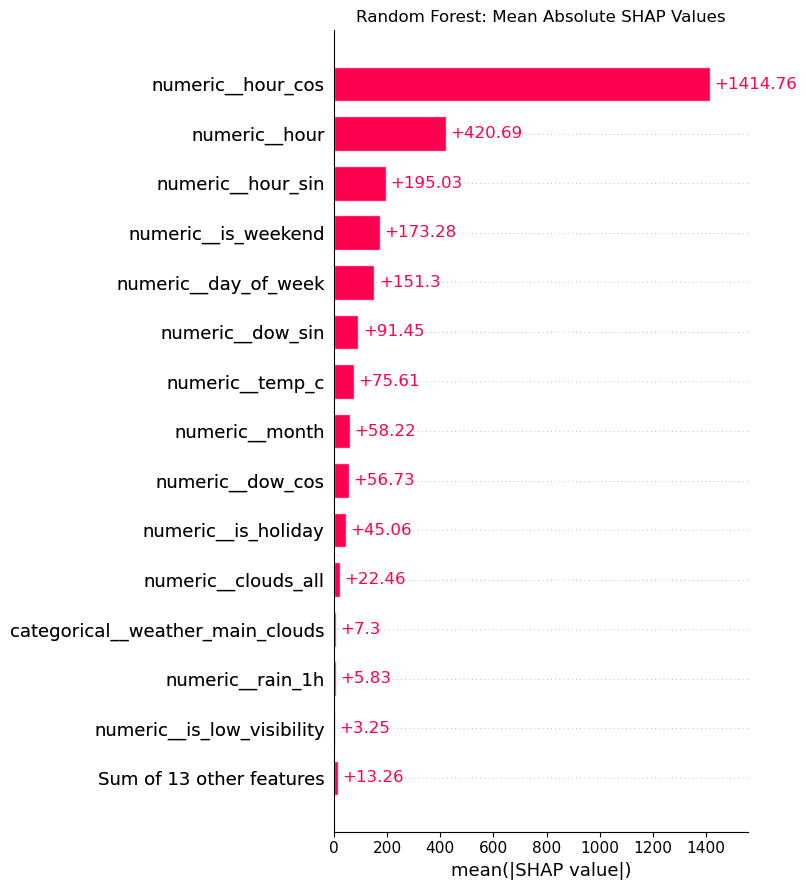

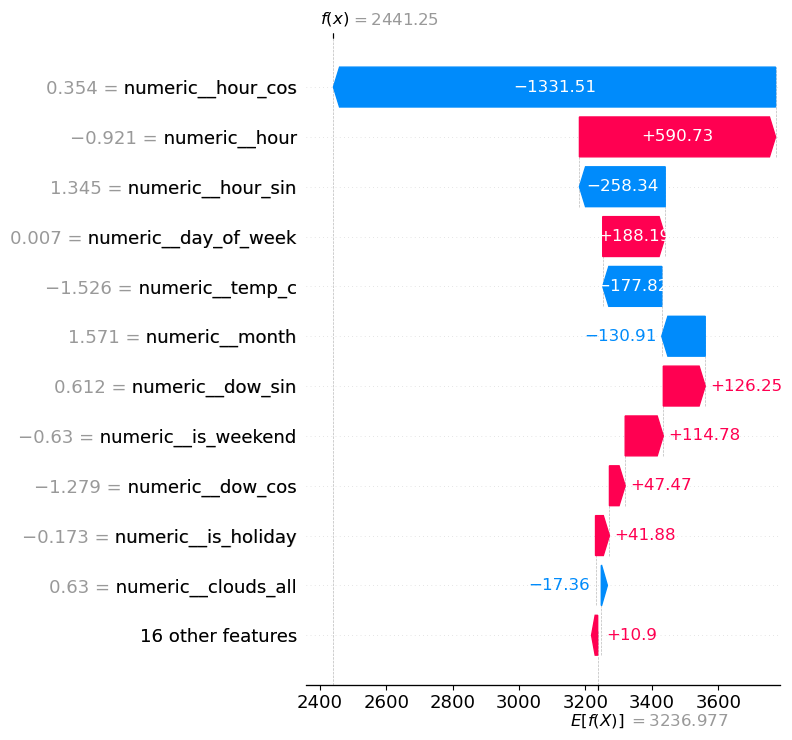

2026-10-10 23:32:14,738 | INFO | part3_preparation | SHAP analysis completed and outputs saved.


,feature,mean_absolute_SHAP
6,numeric__hour_cos,1414.76
0,numeric__hour,420.69
5,numeric__hour_sin,195.03
3,numeric__is_weekend,173.28
1,numeric__day_of_week,151.30
7,numeric__dow_sin,91.45
9,numeric__temp_c,75.61
2,numeric__month,58.22
8,numeric__dow_cos,56.73
4,numeric__is_holiday,45.06


In [17]:
import shap

# 학습된 Random Forest와 전처리기
rf_pipeline = regression_models["RandomForest"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# 계산 시간을 줄이기 위해 검증 데이터 200건 분석
explain_sample = X_validation.sample(
    n=min(200, len(X_validation)),
    random_state=42
)

explain_transformed = rf_preprocessor.transform(explain_sample)
transformed_names = rf_preprocessor.get_feature_names_out()

logger.info(
    "Starting SHAP analysis | validation samples=%d",
    len(explain_sample)
)

# 트리 모델용 SHAP
explainer = shap.TreeExplainer(
    rf_model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer(explain_transformed)

# 그래프에 표시할 특성 이름 지정
shap_values.feature_names = list(transformed_names)

# 1) 표본 전체의 평균적인 특성 기여 크기
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Random Forest: Mean Absolute SHAP Values")
plt.tight_layout()
plt.savefig(
    figures_folder / "shap_global_importance.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

# 2) 첫 번째 표본의 개별 예측 설명
shap.plots.waterfall(
    shap_values[0],
    max_display=12,
    show=False
)
plt.tight_layout()
plt.savefig(
    figures_folder / "shap_local_explanation.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

# 중요도 수치 저장
shap_importance = pd.DataFrame({
    "feature": transformed_names,
    "mean_absolute_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_absolute_SHAP", ascending=False)

shap_importance.to_csv(
    reports_folder / "shap_feature_importance.csv",
    index=False
)

# 설명한 표본과 개별 기여값 저장
explain_sample.to_csv(
    reports_folder / "shap_explained_samples.csv",
    index_label="source_row_index"
)

pd.DataFrame(
    shap_values.values,
    columns=transformed_names,
    index=explain_sample.index
).to_csv(
    reports_folder / "shap_values.csv",
    index_label="source_row_index"
)

logger.info("SHAP analysis completed and outputs saved.")

display(shap_importance.head(10).round(2))

In [18]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [19]:
import mlflow
import platform

# 실험 기록은 Part 3 폴더에 저장
tracking_db = (part3_folder / "mlflow.db").resolve()
artifact_folder = (part3_folder / "mlflow_artifacts").resolve()
artifact_folder.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri("sqlite:///" + tracking_db.as_posix())

experiment_name = "Smart_City_Traffic"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location=artifact_folder.as_uri()
    )

mlflow.set_experiment(experiment_name)

# 기록할 모델과 검증 성능 정리
experiments_to_log = []

for name, model in regression_models.items():
    row = regression_comparison.set_index("model").loc[name]
    experiments_to_log.append((
        "regression", name, model, row.to_dict()
    ))

experiments_to_log.append((
    "regression",
    "NeuralNetwork_MLP",
    neural_network_model,
    nn_validation_results.drop(columns="model").iloc[0].to_dict()
))

for name, model in classification_models.items():
    row = classification_comparison.set_index("model").loc[name]
    experiments_to_log.append((
        "proxy_classification", name, model, row.to_dict()
    ))

run_records = []

for task, name, model, metrics in experiments_to_log:
    with mlflow.start_run(run_name=f"{task}_{name}_v1") as run:
        mlflow.set_tags({
            "task": task,
            "model_version": "v1",
            "logging_method": "post_training",
            "split_method": "chronological_unique_timestamps",
            "classification_target": "proxy_not_actual_accidents"
        })

        mlflow.log_params({
            "train_rows": len(train_features),
            "validation_rows": len(validation_features),
            "input_features": len(feature_columns),
            "sklearn_version": sklearn.__version__,
            "python_version": platform.python_version()
        })

        # 実際に使用したモデル設定を記録
        if name == "NeuralNetwork_MLP":
            estimator = model.regressor_.named_steps["model"]
        else:
            estimator = model.named_steps["model"]

        mlflow.log_params({
            f"model_{key}": str(value)
            for key, value in estimator.get_params(deep=False).items()
        })

        mlflow.log_metrics({
            key: float(value)
            for key, value in metrics.items()
        })

        # 再現に必要な前処理情報
        mlflow.log_artifact(
            str(models_folder / "preparation_settings.joblib"),
            artifact_path="preparation"
        )

        # 모델을 압축 파일로 저장하고 해당 실험에 첨부
        model_path = models_folder / f"{task}_{name}_v1.joblib"
        joblib.dump(model, model_path, compress=3)

        mlflow.log_artifact(
            str(model_path),
            artifact_path="model"
        )

        run_records.append({
            "task": task,
            "model": name,
            "version": "v1",
            "run_id": run.info.run_id,
            **metrics
        })

        logger.info(
            "MLflow run saved | model=%s | run_id=%s",
            name, run.info.run_id
        )

mlflow_summary = pd.DataFrame(run_records)

mlflow_summary.to_csv(
    reports_folder / "mlflow_run_summary.csv",
    index=False
)

display(mlflow_summary[["task", "model", "version", "run_id"]])

2026/10/10 23:37:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/10 23:37:59 INFO mlflow.store.db.utils: Updating database tables
2026/10/10 23:38:01 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a rais

,task,model,version,run_id
0,regression,Ridge,v1,9a80308bcc4f4098a2ba96dbba5c7321
1,regression,RandomForest,v1,6da56499310b4637834030837360f060
2,regression,NeuralNetwork_MLP,v1,edb0f41878b949cf9f68b78049550101
3,proxy_classification,LogisticRegression,v1,f51b46a761814c6687cc2d9528d808aa
4,proxy_classification,RandomForest,v1,c4da0c0c86af4789add2e385b37f19aa


In [20]:
import subprocess
import sys

# 이미 실행 중이면 중복으로 열지 않기
if (
    "mlflow_ui_process" not in globals()
    or mlflow_ui_process.poll() is not None
):
    mlflow_ui_log = open(
        part3_folder / "mlflow_ui.log",
        "a",
        encoding="utf-8"
    )

    mlflow_ui_process = subprocess.Popen(
        [
            sys.executable, "-m", "mlflow", "ui",
            "--backend-store-uri",
            "sqlite:///" + tracking_db.as_posix(),
            "--host", "127.0.0.1",
            "--port", "5000"
        ],
        cwd=str(part3_folder),
        stdout=mlflow_ui_log,
        stderr=subprocess.STDOUT
    )

    logger.info("MLflow UI starting at http://127.0.0.1:5000")
else:
    logger.info("MLflow UI is already running.")

2026-10-10 23:39:40,756 | INFO | part3_preparation | MLflow UI starting at http://127.0.0.1:5000


In [21]:
# Task 5: Travel timing recommendation
import logging

recommendation_logger = logging.getLogger("travel_recommendation")

# 같은 시간·날씨의 반복 기록을 먼저 평균 처리
hourly_history = (
    train_features
    .groupby(["date_time", "weather_main"], as_index=False)
    .agg(traffic_volume=("traffic_volume", "mean"))
)

hourly_history["hour"] = hourly_history["date_time"].dt.hour
hourly_history["day_type"] = np.where(
    hourly_history["date_time"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

# 훈련 데이터로만 추천 기준 생성
travel_profiles = (
    hourly_history
    .groupby(["day_type", "weather_main", "hour"], as_index=False)
    .agg(
        average_traffic=("traffic_volume", "mean"),
        observed_hours=("date_time", "nunique")
    )
)

def recommend_travel(
    day_type="Weekday",
    weather="clear",
    start_hour=6,
    end_hour=10,
    top_n=3
):
    if day_type not in ["Weekday", "Weekend"]:
        raise ValueError("Use Weekday or Weekend.")
    if not 0 <= start_hour <= end_hour <= 23:
        raise ValueError("Hours must satisfy 0 <= start <= end <= 23.")
    if top_n < 1:
        raise ValueError("top_n must be at least 1.")

    candidates = travel_profiles.loc[
        (travel_profiles["day_type"] == day_type)
        & (travel_profiles["weather_main"] == weather.strip().lower())
        & (travel_profiles["hour"].between(start_hour, end_hour))
        & (travel_profiles["observed_hours"] >= 10)
    ].copy()

    if candidates.empty:
        recommendation_logger.warning(
            "Insufficient historical observations for requested conditions."
        )
        return candidates

    result = (
        candidates
        .sort_values(["average_traffic", "hour"])
        .head(top_n)
        .reset_index(drop=True)
    )
    result.insert(0, "rank", range(1, len(result) + 1))
    result["departure_time"] = result["hour"].map(
        lambda hour: f"{hour:02d}:00"
    )
    result["average_traffic"] = result["average_traffic"].round(2)
    result["reason"] = (
        "Lower historical mean traffic within the requested "
        "time window, day type and weather."
    )

    recommendation_logger.info(
        "Generated %d recommendations: %s, %s, %02d-%02d",
        len(result), day_type, weather, start_hour, end_hour
    )
    return result

recommendations = recommend_travel(
    day_type="Weekday",
    weather="clear",
    start_hour=6,
    end_hour=10
)

travel_profiles.to_csv(
    reports_folder / "travel_timing_profiles.csv", index=False
)
recommendations.to_csv(
    reports_folder / "travel_recommendation_example.csv", index=False
)

display(recommendations)

2026-10-10 23:57:34,390 | INFO | travel_recommendation | Generated 3 recommendations: Weekday, clear, 06-10


,rank,day_type,weather_main,hour,average_traffic,observed_hours,departure_time,reason
0,1,Weekday,clear,10,4472.42,241,10:00,Lower historical mean traffic within the reque...
1,2,Weekday,clear,9,4971.31,232,09:00,Lower historical mean traffic within the reque...
2,3,Weekday,clear,6,5502.19,263,06:00,Lower historical mean traffic within the reque...


2026-10-10 23:58:55,458 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-10 23:58:55,475 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


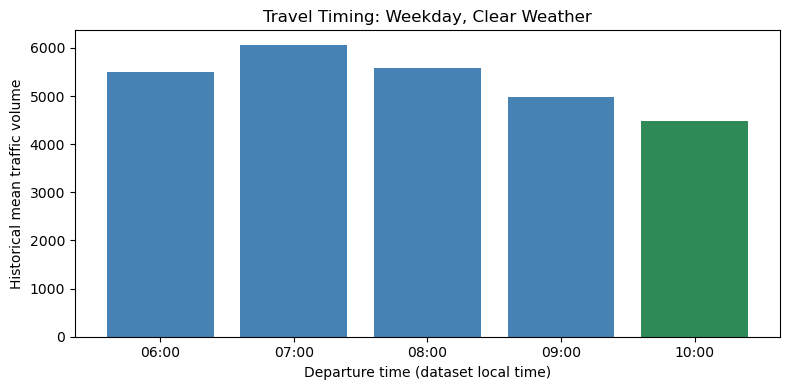

2026-10-10 23:58:56,219 | INFO | travel_recommendation | Saved travel timing comparison chart.


In [22]:
# Compare all eligible hours in the requested window
comparison = travel_profiles.loc[
    (travel_profiles["day_type"] == "Weekday")
    & (travel_profiles["weather_main"] == "clear")
    & (travel_profiles["hour"].between(6, 10))
    & (travel_profiles["observed_hours"] >= 10)
].sort_values("hour")

best_hour = recommendations.iloc[0]["hour"]
colors = [
    "seagreen" if hour == best_hour else "steelblue"
    for hour in comparison["hour"]
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    comparison["hour"].map(lambda h: f"{h:02d}:00"),
    comparison["average_traffic"],
    color=colors
)
ax.set_title("Travel Timing: Weekday, Clear Weather")
ax.set_xlabel("Departure time (dataset local time)")
ax.set_ylabel("Historical mean traffic volume")
ax.set_ylim(bottom=0)
fig.tight_layout()

fig.savefig(
    figures_folder / "travel_timing_recommendation.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

recommendation_logger.info("Saved travel timing comparison chart.")